<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Cryogenic_Classical_Memories_with_Graphviz_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Using Python 3.13.15 environment at: /usr
Checked 2 packages in 416ms


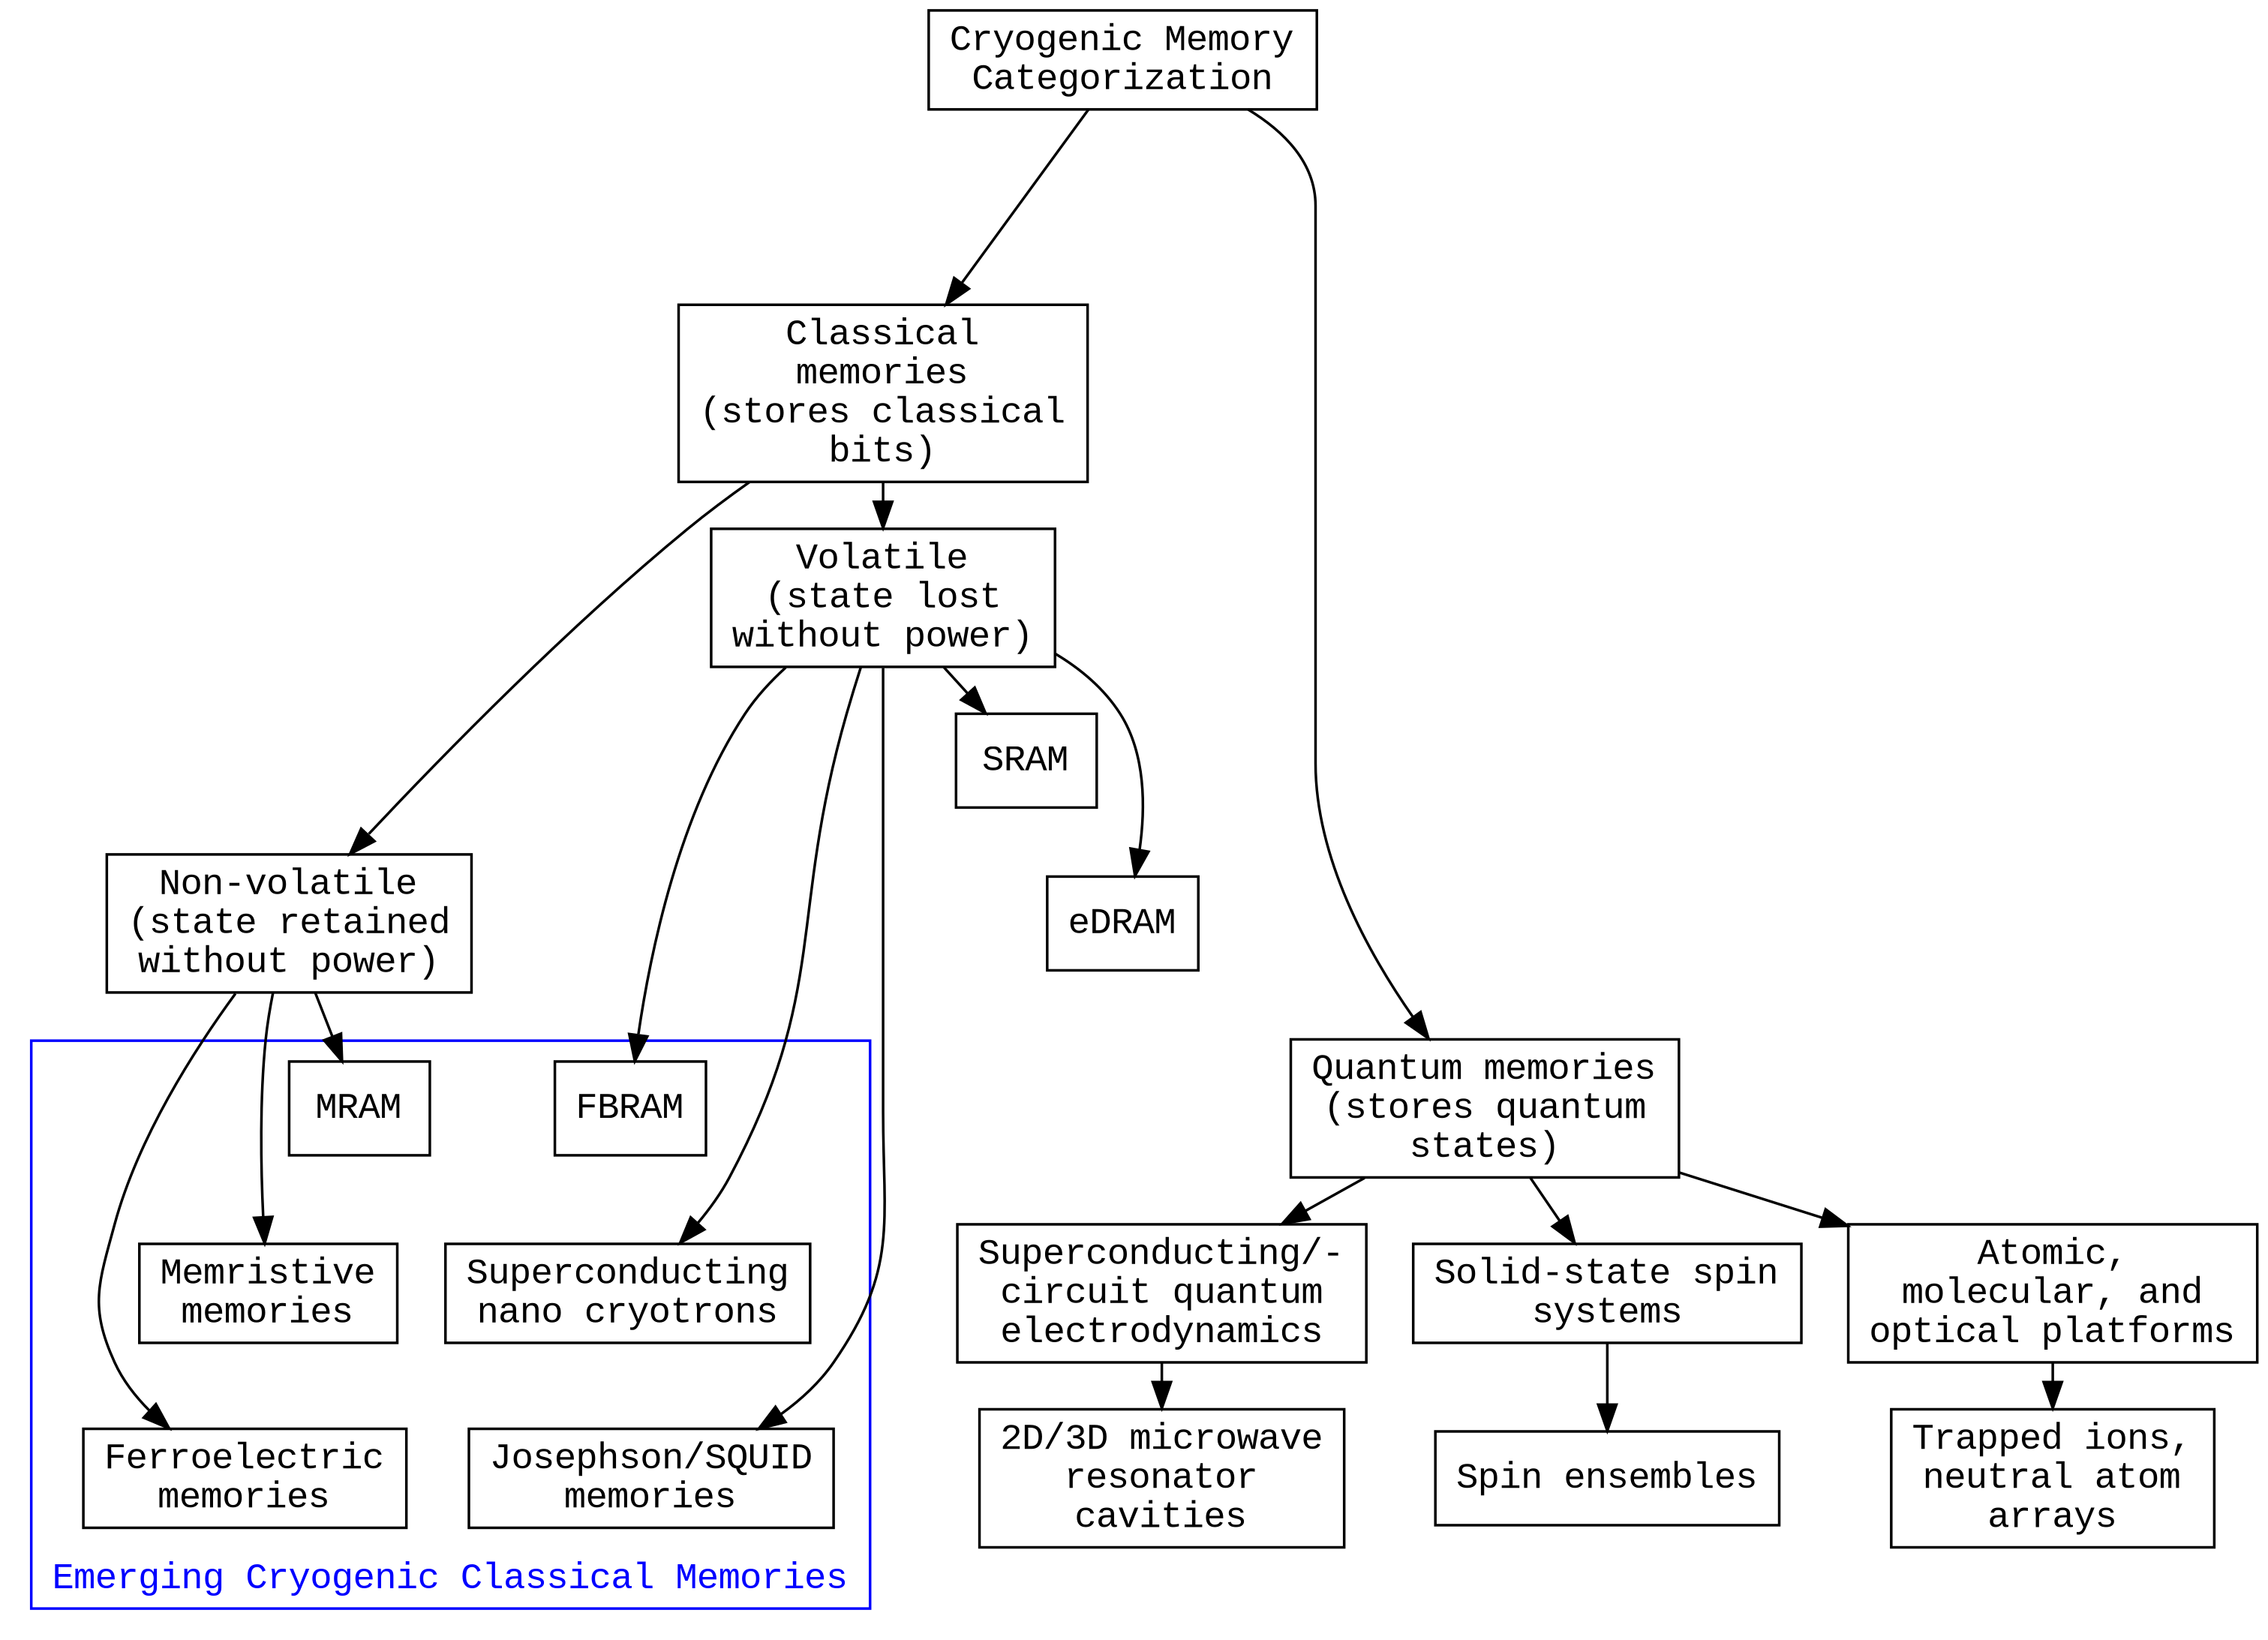

In [25]:
!uv pip install graphviz ipython

"""This script constructs a directed memory classification graph and renders it as an in-memory downloadable object.

The graph avoids orthogonal edges and maintains an absolute monochrome aesthetic for the primary nodes, adding a pure blue bounding box for emerging classical technologies. Control parameters defined at the script level dictate the precise font, resolution, and vertical spacing characteristics. The script applies a hard character limit to each graphical node, cascades primary branches, and stretches the diagram vertically. The output displays an interactive button permitting users to retrieve the image.
"""

import base64
import graphviz
from IPython.display import display, Image, HTML

# Control Knobs
GRAPH_DPI = "250"
NODE_FONT = "DejaVu Sans"
NODE_FONT_WEIGHT = "normal"
EDGE_ROUTING = "spline"
NODE_SHAPE = "box"
BACKGROUND_COLOR = "white"
FOREGROUND_COLOR = "black"
CLUSTER_COLOR = "blue"
RANK_DIRECTION = "TB"
MAX_CHARACTERS_PER_LINE = 17
RANK_SEPARATION = "0.25"     # Adjusts the global vertical stretch
BRANCH_STAGGER_STEP = 4      # Multiplies the vertical drop distance
EMERGING_VOL_OFFSET = 2      # Adjusts the vertical stagger start for emerging volatile memories
EMERGING_NVOL_OFFSET = 0     # Adjusts the vertical stagger start for emerging non-volatile memories

def wrap_text(text: str, max_width: int = MAX_CHARACTERS_PER_LINE) -> str:
    """Wraps text to a specified maximum width, hyphenating oversized strings.

    Args:
        text: The original string input.
        max_width: The maximum allowable characters per line.

    Returns:
        A formatted string featuring newline characters at proper intervals.
    """
    lines = []
    for paragraph in text.split('\n'):
        current_line = ""
        words = paragraph.split()
        for word in words:
            while len(word) > max_width:
                if current_line:
                    lines.append(current_line)
                    current_line = ""
                chunk = word[:max_width - 1] + "-"
                lines.append(chunk)
                word = word[max_width - 1:]

            if current_line:
                if len(current_line) + 1 + len(word) <= max_width:
                    current_line += " " + word
                else:
                    lines.append(current_line)
                    current_line = word
            else:
                current_line = word
        if current_line:
            lines.append(current_line)
    return '\n'.join(lines)

def build_memory_categorization_tree() -> graphviz.Digraph:
    """Constructs the directed Graphviz object outlining the memory classifications."""
    tree = graphviz.Digraph(format='png')

    tree.attr(dpi=GRAPH_DPI, splines=EDGE_ROUTING, bgcolor=BACKGROUND_COLOR, rankdir=RANK_DIRECTION, ranksep=RANK_SEPARATION)
    tree.attr('node', shape=NODE_SHAPE, style='solid', color=FOREGROUND_COLOR, fontcolor=FOREGROUND_COLOR, fontname=NODE_FONT)
    tree.attr('edge', color=FOREGROUND_COLOR, arrowhead='normal')

    tree.node('Root', wrap_text('Cryogenic Memory Categorization'))

    def add_staggered_leaves(node_graph: graphviz.Digraph, edge_graph: graphviz.Digraph, parent_id: str, leaves: list, start_idx: int = 0) -> None:
        """Helper function to attach leaf nodes and stagger them vertically."""
        previous_leaf_id = None
        for idx, leaf_text in enumerate(leaves):
            leaf_id = f'{parent_id}_L_{start_idx + idx}'
            node_graph.node(leaf_id, wrap_text(leaf_text))
            edge_graph.edge(parent_id, leaf_id, minlen=str(start_idx + idx + 1))

            # Force vertical alignment among sibling leaf nodes
            if previous_leaf_id is not None:
                node_graph.edge(previous_leaf_id, leaf_id, style='invis')
            previous_leaf_id = leaf_id

    # Classical Memory Branch
    tree.node('Class', wrap_text('Classical memories\n(stores classical bits)'))
    tree.edge('Root', 'Class', minlen=str(1 * BRANCH_STAGGER_STEP))

    tree.node('Class_Vol', wrap_text('Volatile\n(state lost without power)'))
    tree.edge('Class', 'Class_Vol')

    # Standard Volatile Leaves
    add_staggered_leaves(tree, tree, 'Class_Vol', ['SRAM', 'eDRAM'], start_idx=0)

    tree.node('Class_NVol', wrap_text('Non-volatile\n(state retained without power)'))
    tree.edge('Class', 'Class_NVol')

    # Emerging Cryogenic Classical Memories Cluster
    with tree.subgraph(name='cluster_emerging') as c:
        c.attr(color=CLUSTER_COLOR, style='solid', fillcolor='none')
        c.attr(label='Emerging Cryogenic Classical Memories', labelloc='b', labeljust='r', fontcolor=CLUSTER_COLOR, fontname=NODE_FONT)

        # Route emerging leaves from the primary classical nodes into the bounding box
        add_staggered_leaves(c, tree, 'Class_Vol', ['FBRAM', 'Superconducting nano cryotrons', 'Josephson/SQUID memories'], start_idx=EMERGING_VOL_OFFSET)
        add_staggered_leaves(c, tree, 'Class_NVol', ['MRAM', 'Memristive memories', 'Ferroelectric memories'], start_idx=EMERGING_NVOL_OFFSET)

    # Quantum Memory Branch
    tree.node('Quant', wrap_text('Quantum memories\n(stores quantum states)'))
    tree.edge('Root', 'Quant', minlen=str(2 * BRANCH_STAGGER_STEP))

    tree.node('Quant_SC', wrap_text('Superconducting/circuit quantum electrodynamics'))
    tree.edge('Quant', 'Quant_SC')
    add_staggered_leaves(tree, tree, 'Quant_SC', ['2D/3D microwave resonator cavities'])

    tree.node('Quant_Spin', wrap_text('Solid-state spin systems'))
    tree.edge('Quant', 'Quant_Spin')
    add_staggered_leaves(tree, tree, 'Quant_Spin', ['Spin ensembles'])

    tree.node('Quant_AMO', wrap_text('Atomic, molecular, and optical platforms'))
    tree.edge('Quant', 'Quant_AMO')
    add_staggered_leaves(tree, tree, 'Quant_AMO', ['Trapped ions, neutral atom arrays'])

    return tree

def display_and_generate_download(tree: graphviz.Digraph) -> None:
    """Renders the graph in memory and constructs a base64 encoded download button."""
    binary_png = tree.pipe(format='png')

    display(Image(data=binary_png))

    encoded_image = base64.b64encode(binary_png).decode('utf-8')

if __name__ == '__main__':
    memory_tree = build_memory_categorization_tree()
    display_and_generate_download(memory_tree)

Using Python 3.13.15 environment at: /usr
Checked 2 packages in 67ms


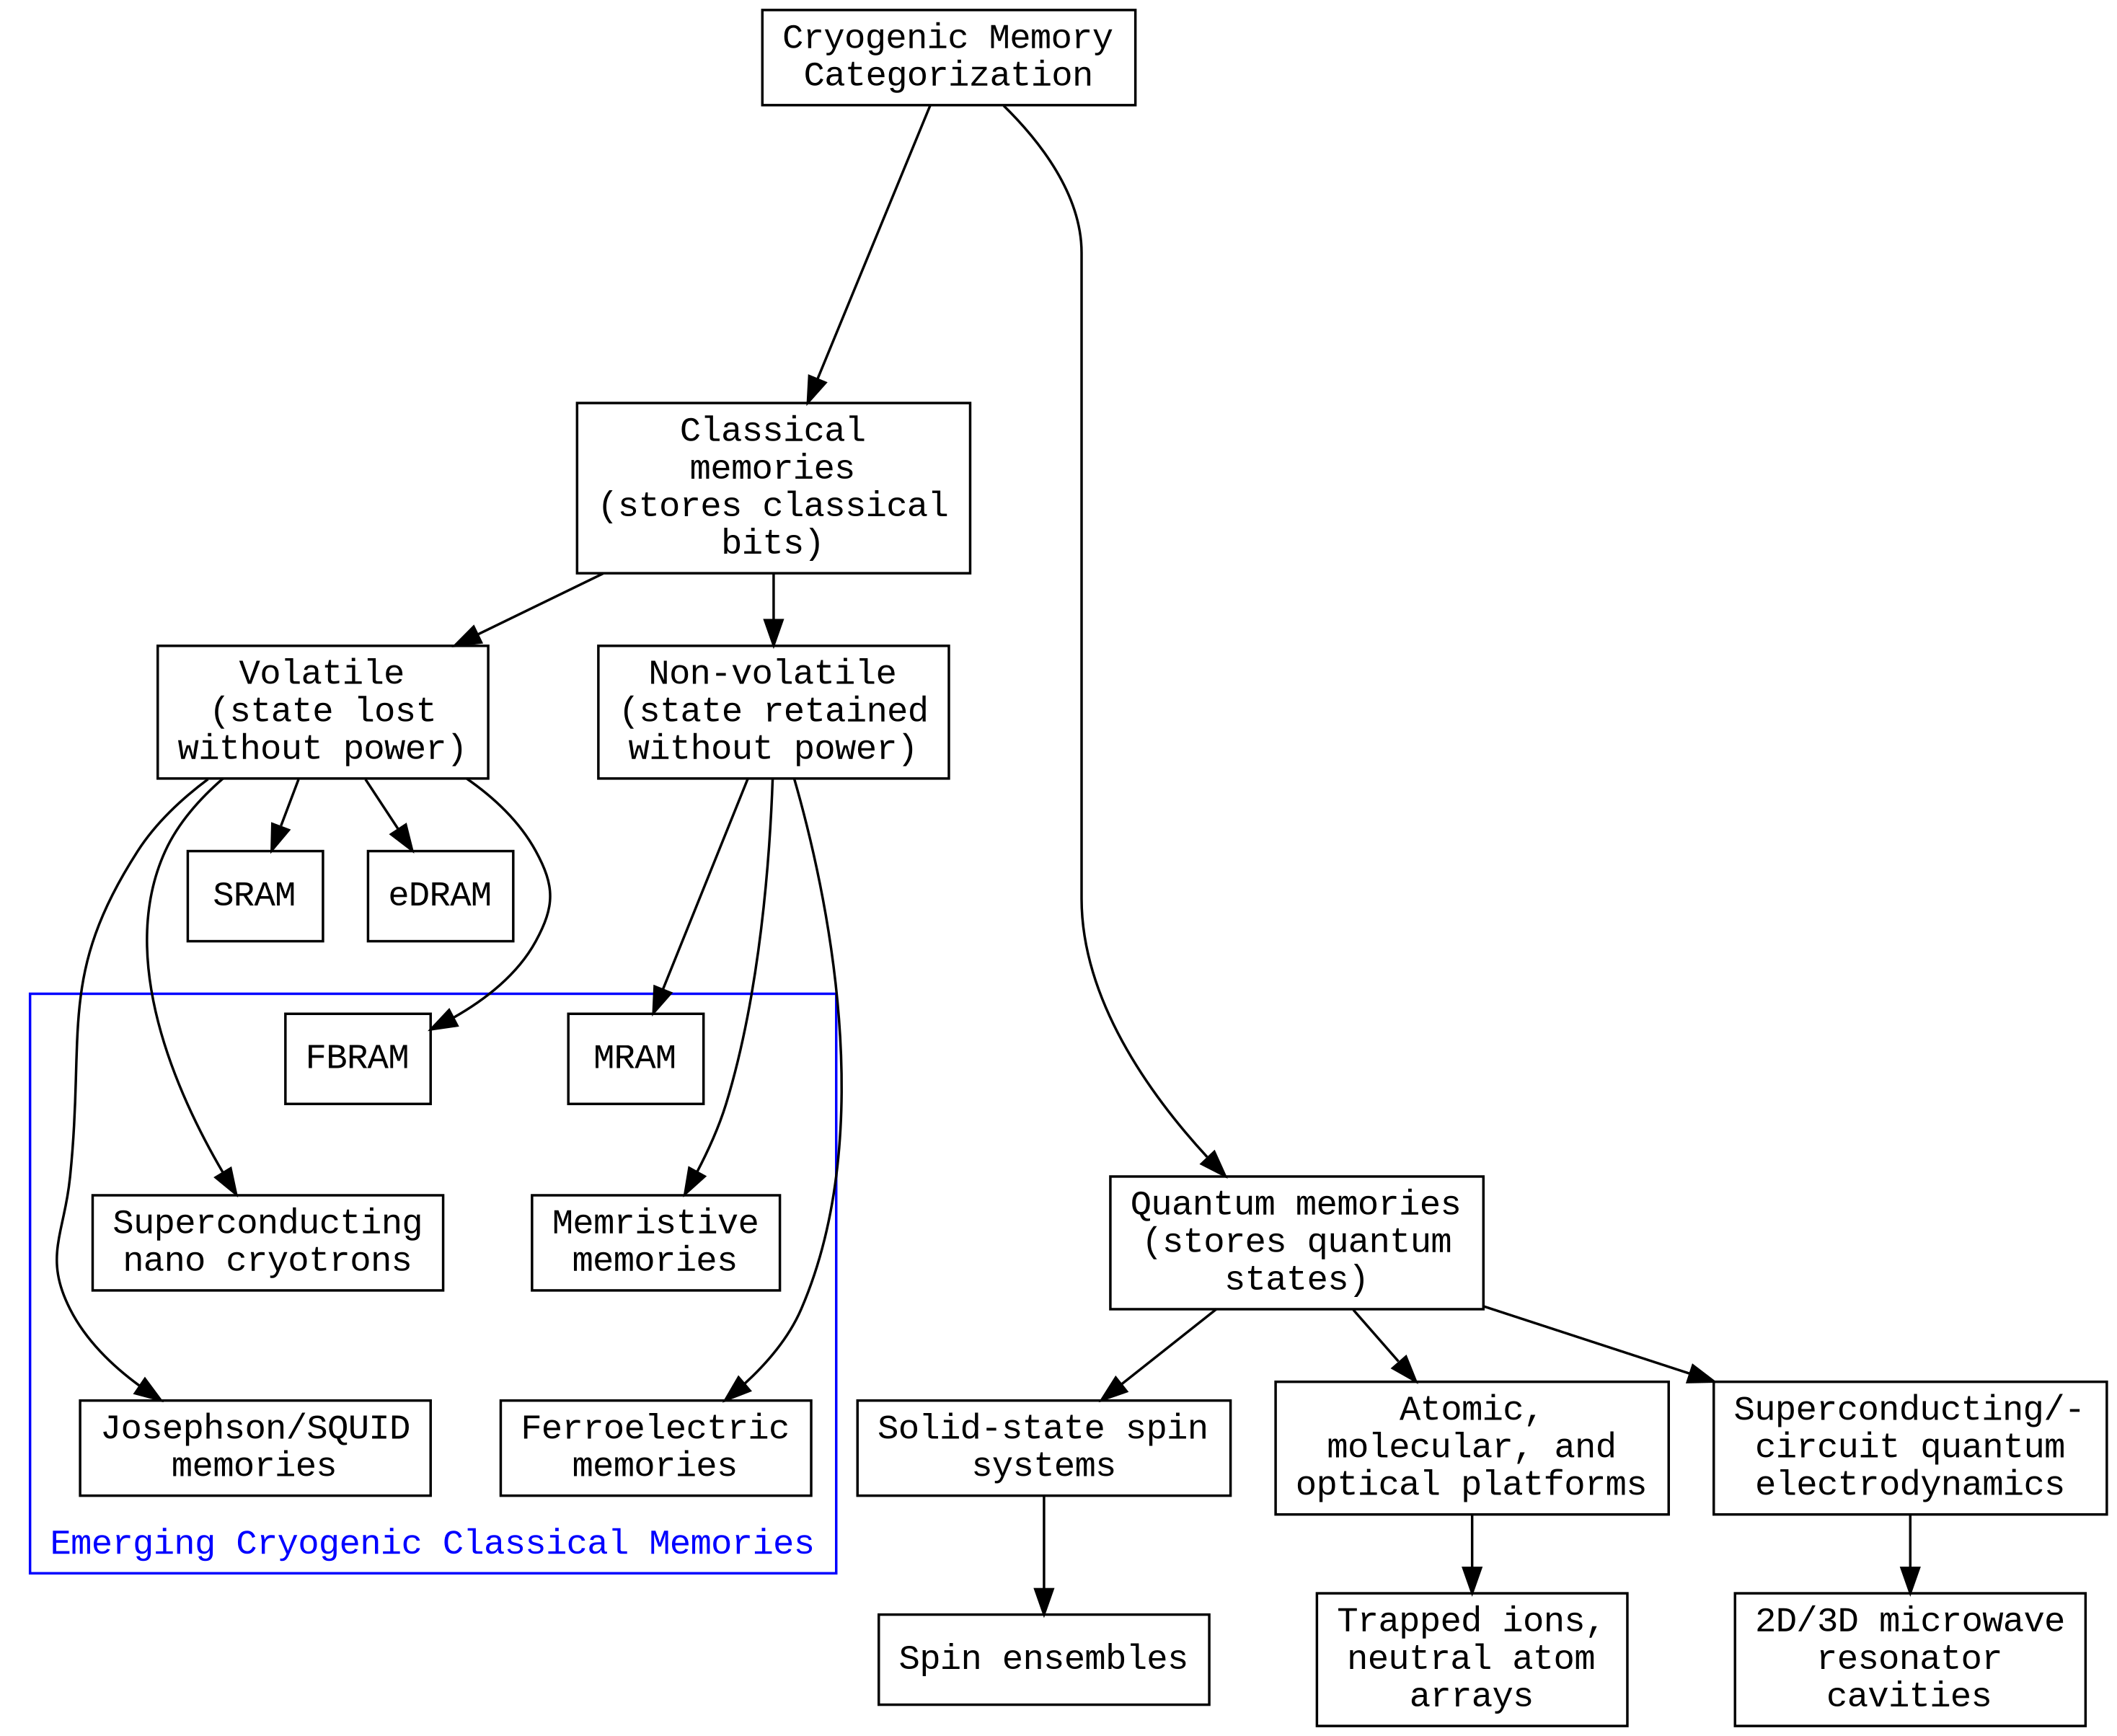

In [24]:
!uv pip install graphviz ipython

"""This script constructs a directed memory classification graph and renders it as an in-memory downloadable object.

The graph avoids orthogonal edges and maintains an absolute monochrome aesthetic for the primary nodes, adding a pure blue bounding box for emerging classical technologies. Control parameters defined at the script level dictate the precise font, resolution, and vertical spacing characteristics. The script applies a hard character limit to each graphical node, cascades primary branches, and stretches the diagram vertically. The output displays an interactive button permitting users to retrieve the image.
"""

import base64
import graphviz
from IPython.display import display, Image, HTML

# Control Knobs
GRAPH_DPI = "250"
NODE_FONT = "DejaVu Sans"
NODE_FONT_WEIGHT = "normal"
EDGE_ROUTING = "spline"
NODE_SHAPE = "box"
BACKGROUND_COLOR = "white"
FOREGROUND_COLOR = "black"
CLUSTER_COLOR = "blue"
RANK_DIRECTION = "TB"
MAX_CHARACTERS_PER_LINE = 17
RANK_SEPARATION = "0.4"     # Increased slightly to give the staggered nodes room
BRANCH_STAGGER_STEP = 4      # Multiplies the vertical drop distance

def wrap_text(text: str, max_width: int = MAX_CHARACTERS_PER_LINE) -> str:
    """Wraps text to a specified maximum width, hyphenating oversized strings."""
    lines = []
    for paragraph in text.split('\n'):
        current_line = ""
        words = paragraph.split()
        for word in words:
            while len(word) > max_width:
                if current_line:
                    lines.append(current_line)
                    current_line = ""
                chunk = word[:max_width - 1] + "-"
                lines.append(chunk)
                word = word[max_width - 1:]

            if current_line:
                if len(current_line) + 1 + len(word) <= max_width:
                    current_line += " " + word
                else:
                    lines.append(current_line)
                    current_line = word
            else:
                current_line = word
        if current_line:
            lines.append(current_line)
    return '\n'.join(lines)

def build_memory_categorization_tree() -> graphviz.Digraph:
    """Constructs the directed Graphviz object outlining the memory classifications."""
    tree = graphviz.Digraph(format='png')

    tree.attr(dpi=GRAPH_DPI, splines=EDGE_ROUTING, bgcolor=BACKGROUND_COLOR, rankdir=RANK_DIRECTION, ranksep=RANK_SEPARATION)
    tree.attr('node', shape=NODE_SHAPE, style='solid', color=FOREGROUND_COLOR, fontcolor=FOREGROUND_COLOR, fontname=NODE_FONT)
    tree.attr('edge', color=FOREGROUND_COLOR, arrowhead='normal')

    tree.node('Root', wrap_text('Cryogenic Memory Categorization'))

    def add_staggered_leaves(node_graph: graphviz.Digraph, edge_graph: graphviz.Digraph, parent_id: str, leaves: list, start_idx: int = 0, force_vertical: bool = False) -> None:
        """
        Helper function to attach leaf nodes.
        If force_vertical is True, it creates invisible edges between siblings to force a vertical stagger.
        """
        prev_id = None
        for idx, leaf_text in enumerate(leaves):
            leaf_id = f'{parent_id}_L_{start_idx + idx}'
            node_graph.node(leaf_id, wrap_text(leaf_text))

            # Edge from parent to child
            # minlen is used to push the group further down from the parent
            edge_graph.edge(parent_id, leaf_id, minlen=str(1 if not force_vertical else 2))

            # The secret for vertical staggering: an invisible edge from the previous sibling
            if force_vertical and prev_id:
                edge_graph.edge(prev_id, leaf_id, style='invis')

            prev_id = leaf_id

    # Classical Memory Branch
    tree.node('Class', wrap_text('Classical memories\n(stores classical bits)'))
    tree.edge('Root', 'Class', minlen=str(1 * BRANCH_STAGGER_STEP))

    tree.node('Class_Vol', wrap_text('Volatile\n(state lost without power)'))
    tree.edge('Class', 'Class_Vol')

    # Standard Volatile Leaves (Not forced vertical, just standard)
    add_staggered_leaves(tree, tree, 'Class_Vol', ['SRAM', 'eDRAM'])

    tree.node('Class_NVol', wrap_text('Non-volatile\n(state retained without power)'))
    tree.edge('Class', 'Class_NVol')

    # Emerging Cryogenic Classical Memories Cluster
    with tree.subgraph(name='cluster_emerging') as c:
        c.attr(color=CLUSTER_COLOR, style='solid', fillcolor='none')
        c.attr(label='Emerging Cryogenic Classical Memories', labelloc='b', labeljust='r', fontcolor=CLUSTER_COLOR, fontname=NODE_FONT)

        # Route emerging leaves with force_vertical=True to ensure they stack
        add_staggered_leaves(c, tree, 'Class_Vol',
                             ['FBRAM', 'Superconducting nano cryotrons', 'Josephson/SQUID memories'],
                             start_idx=10, force_vertical=True)

        add_staggered_leaves(c, tree, 'Class_NVol',
                             ['MRAM', 'Memristive memories', 'Ferroelectric memories'],
                             start_idx=20, force_vertical=True)

    # Quantum Memory Branch
    tree.node('Quant', wrap_text('Quantum memories\n(stores quantum states)'))
    tree.edge('Root', 'Quant', minlen=str(2 * BRANCH_STAGGER_STEP))

    tree.node('Quant_SC', wrap_text('Superconducting/circuit quantum electrodynamics'))
    tree.edge('Quant', 'Quant_SC')
    add_staggered_leaves(tree, tree, 'Quant_SC', ['2D/3D microwave resonator cavities'])

    tree.node('Quant_Spin', wrap_text('Solid-state spin systems'))
    tree.edge('Quant', 'Quant_Spin')
    add_staggered_leaves(tree, tree, 'Quant_Spin', ['Spin ensembles'])

    tree.node('Quant_AMO', wrap_text('Atomic, molecular, and optical platforms'))
    tree.edge('Quant', 'Quant_AMO')
    add_staggered_leaves(tree, tree, 'Quant_AMO', ['Trapped ions, neutral atom arrays'])

    return tree

def display_and_generate_download(tree: graphviz.Digraph) -> None:
    """Renders the graph in memory and constructs a base64 encoded download button."""
    binary_png = tree.pipe(format='png')
    display(Image(data=binary_png))
    encoded_image = base64.b64encode(binary_png).decode('utf-8')

if __name__ == '__main__':
    memory_tree = build_memory_categorization_tree()
    display_and_generate_download(memory_tree)
